In [2]:
import numpy as np
import matplotlib.pyplot as plt
import photutils
from astropy.io import fits
from matplotlib.colors import LogNorm
from photutils.centroids import centroid_2dg
from photutils.profiles import RadialProfile
from astropy.stats import mad_std
from matplotlib.gridspec import GridSpec
import matplotlib.colors as mcolors
import copy
from astropy.cosmology import Planck18 as cosmo
import astropy.units as u
from scipy.special import gamma
from scipy.optimize import least_squares
from scipy.ndimage import uniform_filter1d
from scipy.optimize import curve_fit
from astropy.stats import sigma_clipped_stats

from item_class import item, get_hdu_obj
from trial_class import trial
from plotting import plot_epochs, plot_thres



info = fits.open('../clusters_metadata.fits')
halo_table = info[1].data
halo_lookup = {row['halo_id']: row
               for row in halo_table}


##### getting everything

In [6]:
hdul_old_no_masks = fits.open('/data2/ntova/evaluation of training results/final_predictions.fits')
hdul_old_mask = fits.open('/data2/ntova/evaluation of training results/masked_predictions.fits')
hdul_old_mask_bcg = fits.open('/data2/ntova/evaluation of training results/masked_keep_bcg_predictions.fits')
hdul_old_extend = fits.open('/data2/ntova/evaluation of training results/extended_predictions.fits')
hdul_old_extend_bcg = fits.open('/data2/ntova/evaluation of training results/extended_keep_bcg_predictions.fits')

hdul_old_wo_cir = fits.open('/data2/ntova/evaluation of training results/tot_img_predictions.fits')
hdul_old_cir = fits.open('/data2/ntova/evaluation of training results/tot_cir_predictions.fits')

hdul_300 = fits.open('/net/vdesk/data2/ntova/evaluation of training results/cir_sextractor_2_300_predictions.fits')
hdul_600 = fits.open('/net/vdesk/data2/ntova/evaluation of training results/cir_sextractor_2_600_predictions.fits')
hdul_1000 = fits.open('/net/vdesk/data2/ntova/evaluation of training results/cir_sextractor_2_1000_predictions.fits')

hdul_300_gr = fits.open('/net/vdesk/data2/ntova/evaluation of training results/cir_sextractor_2_300_grown_predictions.fits')
hdul_600_gr = fits.open('/net/vdesk/data2/ntova/evaluation of training results/cir_sextractor_2_600_grown_predictions.fits')
hdul_1000_gr = fits.open('/net/vdesk/data2/ntova/evaluation of training results/cir_sextractor_2_1000_grown_predictions.fits')

XTENSION= 'IMAGE   '           / Image extension                                
BITPIX  =                  -32 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                  256                                                  
NAXIS2  =                  256                                                  
PCOUNT  =                    0 / number of parameters                           
GCOUNT  =                    1 / number of groups                               
MODEL   = 'final   '                                                            
INDEX   =                    0                                                  
HALO_ID =        3741350060877                                                  
DOUBLET =                    1                                                  
TYPE    = 'PRED    '                                                            

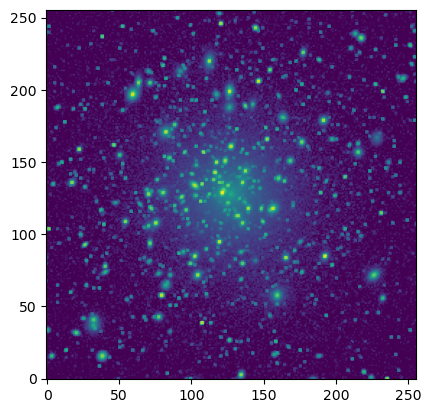

In [ ]:
plt.imshow(10**hdul_old_no_masks[1].data, norm=LogNorm())


7.5


Halo 3840360729382: Re=67.13, n=3.39, bkg=2.447e-01
67.13018881951827
Halo 3840360729382: Re=67.13, n=3.39, bkg=2.447e-01
67.13018881951827
tgcen: [127.49999993 127.49999994] <class 'numpy.ndarray'> (2,)
prcen: [126.81830836 124.92302749] <class 'numpy.ndarray'> (2,)
diffcen: 2.6656125790002485


67.13018881951827

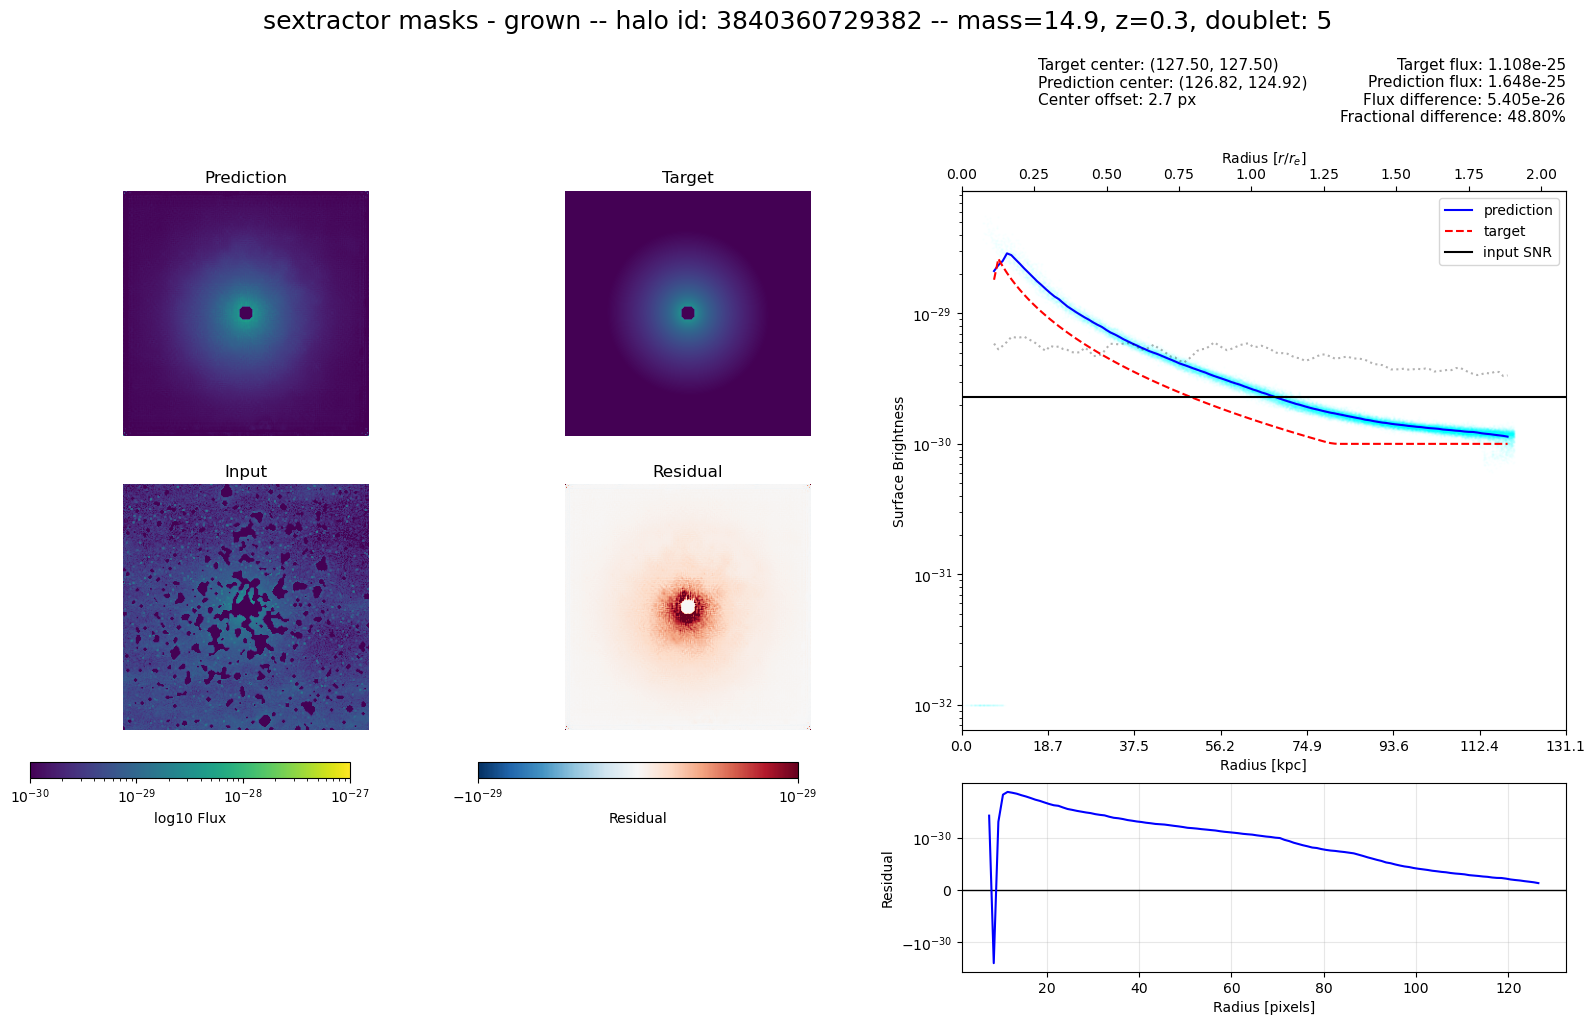

In [4]:
idx=20

obj = item(hdul_300_gr, epochs=300, type='sextractor masks - grown', idx=idx, halo_lookup=halo_lookup, include_bcg=False, bcg_threshold=0.1)
obj.process()
obj.re_from_s_fitting()
#plt.imshow(a.inp, norm=LogNorm(1e-30,1e-26))
obj.plot_item()

obj.icl_re

Halo 3741350060877: Re=50.00, n=4.00, bkg=-1.000e-10
49.99999999999999


(49.99999999999999, 4.0, -1e-10)

In [ ]:
new_masks_trial = trial(hdul_1000_gr, type='mask grown sextractor', epochs=1000, halo_lookup=halo_lookup, bcg_threshold=0.1, include_bcg=False)
old_masks_trial = trial(hdul_old_cir, type='old masks grown', epochs=1000, halo_lookup=halo_lookup, bcg_threshold=0.1, include_bcg=False)


new_masks_trial.process_all_hdus()
old_masks_trial.process_all_hdus()

new_300_gr = trial(hdul_300_gr, type='mask grown sextractor', epochs=300, halo_lookup=halo_lookup, bcg_threshold=0.1, include_bcg=False)
new_300_gr.process_all_hdus()

new_600_gr = trial(hdul_600_gr, type='mask grown sextractor', epochs=600, halo_lookup=halo_lookup, bcg_threshold=0.1, include_bcg=False)
new_600_gr.process_all_hdus()

##### epochs and comparison graphs

In [ ]:
indices=np.arange(1,75,1)

for idx in indices:

    obj = item(hdul_300_gr, epochs=300, type='sextractor masks - grown', idx=idx, halo_lookup=halo_lookup, include_bcg=False, bcg_threshold=0.1)
    obj_2 = item(hdul_600_gr, epochs=600, type='sextractor masks - grown', idx=idx, halo_lookup=halo_lookup, include_bcg=False, bcg_threshold=0.1)
    obj_3 = item(hdul_1000_gr, epochs=1000, type='sextractor masks - grown', idx=idx, halo_lookup=halo_lookup, include_bcg=False, bcg_threshold=0.1)

    items_list = [obj, obj_2, obj_3]
    for i in items_list:
        i.process()

    plot_epochs(items_list, title='Masked BCG Epochs comparison', save='True')

##### power spectra graphs

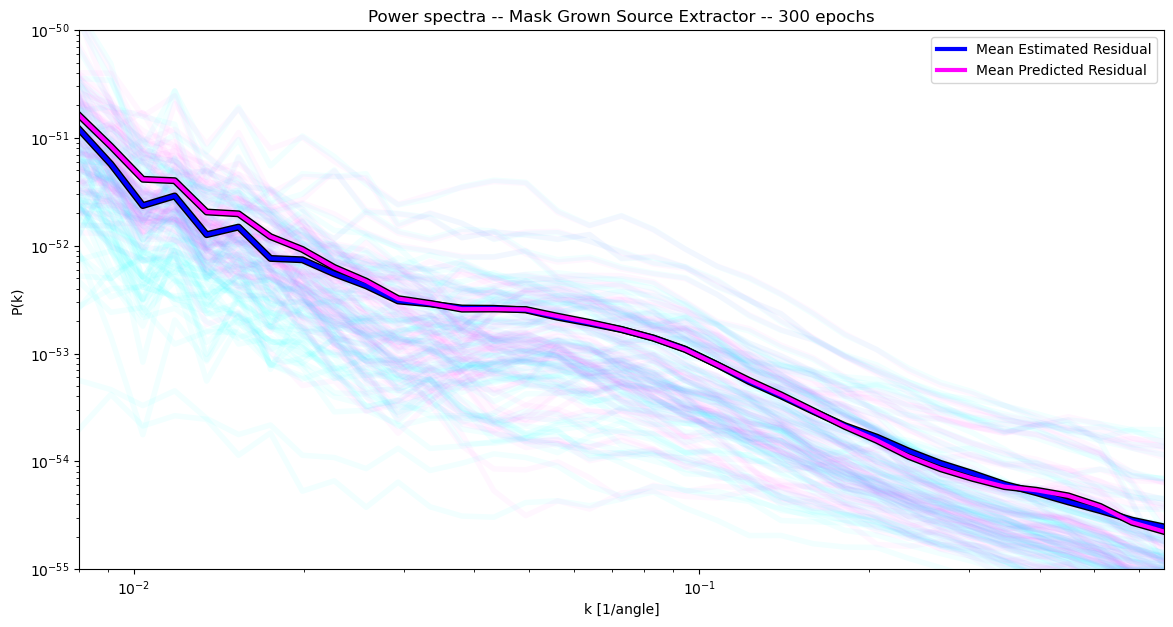

In [68]:
tr = new_300_gr

fig = plt.figure(figsize=(14,7))

k, p = tr.items[0].spectra["Cirrus real (inp - tg)"]

sum_real = np.zeros_like(p)
sum_pred = np.zeros_like(p)

for obj in tr.items:

    k_real, p_real = obj.spectra["Cirrus real (inp - tg)"]
    k_pred, p_pred = obj.spectra["Cirrus est (inp - pr)"]

    plt.loglog(k_real, p_real, color="cyan", alpha=0.05, lw=4)
    plt.loglog(k_pred, p_pred, color="magenta", alpha=0.03, lw=4)

    sum_real += p_real
    sum_pred += p_pred

mean_real = sum_real / len(tr.items)
mean_pred = sum_pred / len(tr.items)

plt.loglog(k, mean_real, color="k", lw=5)
plt.loglog(k, mean_pred, color="k", lw=5)
plt.loglog(k, mean_real, color="blue", lw=3, label="Mean Estimated Residual")
plt.loglog(k, mean_pred, color="magenta", lw=3, label="Mean Predicted Residual")

plt.xlim(8e-3, np.max(k))
plt.ylim(1e-55,1e-50)
plt.xlabel("k [1/angle]")
plt.ylabel("P(k)")
plt.title(f"Power spectra -- Mask Grown Source Extractor -- 300 epochs")


px_scale =2
px=128
image_ang_scale = px*px_scale

#plt.axvline(1/image_ang_scale, color='black', linestyle='--', lw=1, label=f'image size scale ({px}px)')
plt.axvline()
plt.legend()
plt.show()



In [ ]:
tr = new_masks_trial

real = []
pred = []

for obj in tr.items:

    k_real, p_real = obj.spectra["Cirrus real (inp - tg)"]
    k_pred, p_pred = obj.spectra["Cirrus est (inp - pr)"]

    real.append(p_real)
    pred.append(p_pred)

real = np.array(real)
pred = np.array(pred)

log_real = np.log10(real)
log_pred = np.log10(pred)
med_real = 10**np.nanmedian(log_real, axis=0)
med_pred = 10**np.nanmedian(log_pred, axis=0)

q16_real, q84_real = np.nanquantile(log_real, [0.16, 0.84], axis=0)
q16_pred, q84_pred = np.nanquantile(log_pred, [0.16, 0.84], axis=0)

k = tr.items[0].spectra["Cirrus real (inp - tg)"][0]


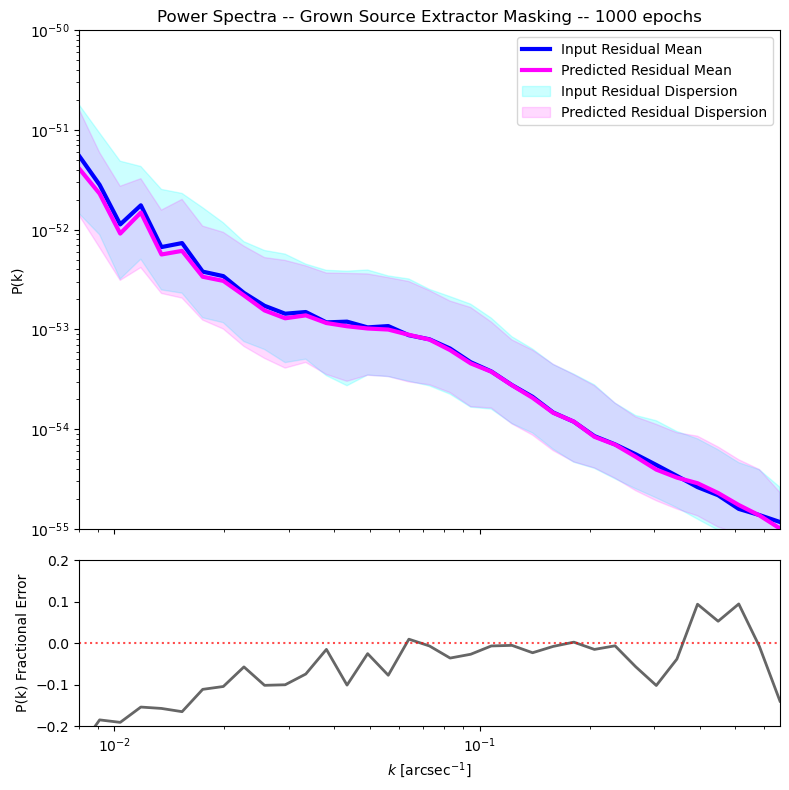

In [122]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), sharex=True, gridspec_kw={"height_ratios": [3, 1]} )

ax1.fill_between( k, 10**q16_real, 10**q84_real, color="cyan", alpha=0.2, label="Input Residual Dispersion" )
ax1.fill_between( k, 10**q16_pred, 10**q84_pred, color="magenta", alpha=0.15, label="Predicted Residual Dispersion" )
ax1.loglog( k, med_real, color="blue", lw=3, label="Input Residual Mean" )
ax1.loglog( k, med_pred, color="magenta", lw=3, label="Predicted Residual Mean" )
ax1.set_xlim(8e-3, np.max(k))
ax1.set_ylim(1e-55, 1e-50)
ax1.set_ylabel("P(k)")
ax1.set_title( "Power Spectra -- Grown Source Extractor Masking -- 1000 epochs" )
ax1.legend()


frac_error = (med_pred - med_real) / med_real
ax2.plot( k, frac_error, color="k", lw=2, alpha=0.6)
ax2.axhline( 0, color="red", linestyle="dotted", alpha=0.7 )
ax2.set_xlim(8e-3, np.max(k))
ax2.set_ylim(-0.2, 0.2)
ax2.set_ylabel("P(k) Fractional Error")
ax2.set_xlabel(r"$k$ [arcsec$^{-1}$]")
ax2.set_xscale("log")

plt.tight_layout()
plt.show()

##### radial profiles

In [5]:
def radial_profile_with_sigma(image, center, nbins=20):

    y, x = np.indices(image.shape)
    cx, cy = center
    r = np.sqrt((x-cx)**2 + (y-cy)**2)

    rmax = r.max()
    bins = np.linspace(0, rmax, nbins+1)
    r_mid = 0.5*(bins[:-1] + bins[1:])

    profile = np.zeros(nbins)
    sigma = np.zeros(nbins)

    for i in range(nbins):

        mask = (r >= bins[i]) & (r < bins[i+1])
        pixels = image[mask]
        pixels = pixels[np.isfinite(pixels)]
        #pixels = pixels[(pixels != 1e-32) & np.isfinite(pixels)]
        #print(len(pixels))
        
        if len(pixels) > 5:

            mean, median, std = sigma_clipped_stats( pixels, sigma=3)
            profile[i] = median
            sigma[i] = std

        else:
            profile[i] = np.nan
            sigma[i] = np.nan


    return r_mid, profile, sigma



Text(0.5, 1.0, 'Halo 3741350060877 -- idx=10')

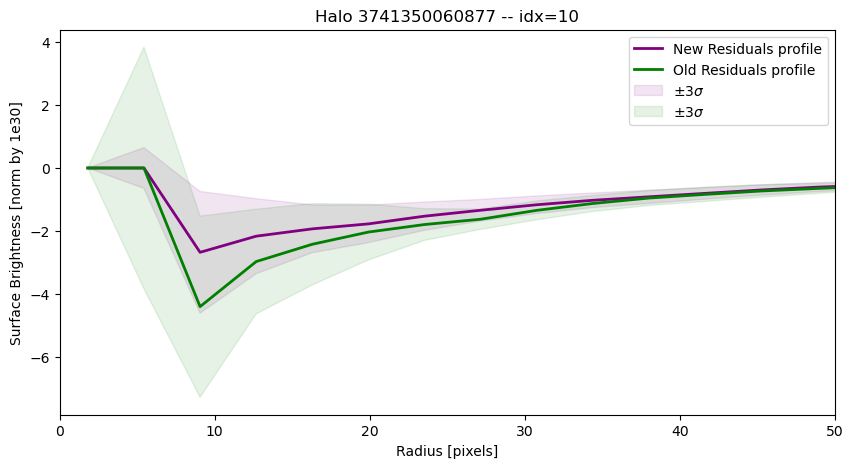

In [7]:
idx=10
it = new_masks_trial.items[idx]
it_old = old_masks_trial.items[idx]
nbins=50

r_mid, profile, sigma = radial_profile_with_sigma(it.res*1e30, (128,128), nbins=nbins)
r_mid_old, profile_old, sigma_old = radial_profile_with_sigma(it_old.res*1e30, (128,128), nbins=nbins)

plt.figure(figsize=(10,5))
plt.plot(r_mid, profile, color='purple', lw=2, label='New Residuals profile')
plt.fill_between( r_mid, profile - sigma, profile + sigma, color='purple', alpha=0.1, label=r'$\pm3\sigma$' )

plt.plot(r_mid_old, profile_old, color='green', lw=2, label='Old Residuals profile')
plt.fill_between( r_mid_old, profile_old - sigma_old, profile_old + sigma_old, color='green', alpha=0.1, label=r'$\pm3\sigma$' )

plt.xlim(0,50)
plt.xlabel("Radius [pixels]")
plt.ylabel("Surface Brightness [norm by 1e30]")
plt.legend()
plt.title(f'Halo {it.halo_id} -- idx={it.idx}')

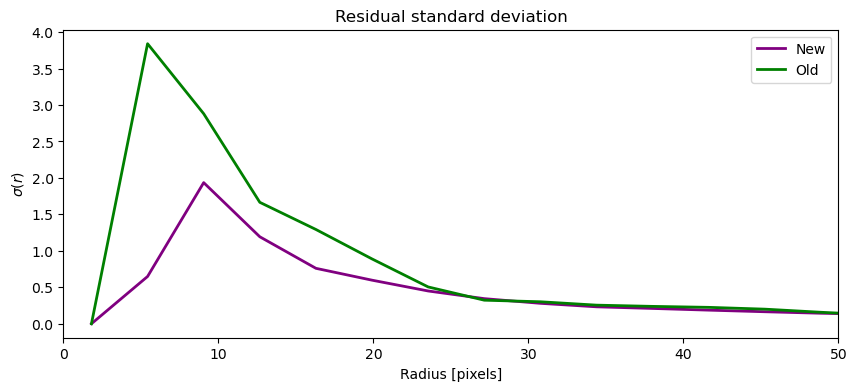

In [8]:
plt.figure(figsize=(10,4))
plt.plot(r_mid, sigma, lw=2, color='purple', label='New')
plt.plot(r_mid_old, sigma_old, lw=2, color='green', label='Old')
plt.xlabel("Radius [pixels]")
plt.xlim(0,50)
plt.ylabel(r"$\sigma(r)$")
plt.title("Residual standard deviation")
plt.legend()
plt.show()

In [9]:
def sum_sigma(tr,nbins=50):

    sum_profile = None
    sum_sigma = None


    for obj in tr.items:

        residual = obj.res

        if not hasattr(obj, "tgcen"):
            obj.find_centers()

        r, prof, sig = radial_profile_with_sigma(
            residual*1e30,
            obj.tgcen,
            nbins=nbins
        )

        if sum_profile is None:
            sum_profile = np.zeros_like(prof)
            sum_sigma = np.zeros_like(sig)

        sum_profile += prof
        sum_sigma += sig

    # Mean profile
    mean_profile = sum_profile / len(tr.items)
    mean_sigma = sum_sigma / len(tr.items)

    return mean_profile, mean_sigma


mean_prof_old, mean_sigma_old = sum_sigma(old_masks_trial)
mean_prof_new, mean_sigma_new = sum_sigma(new_masks_trial)


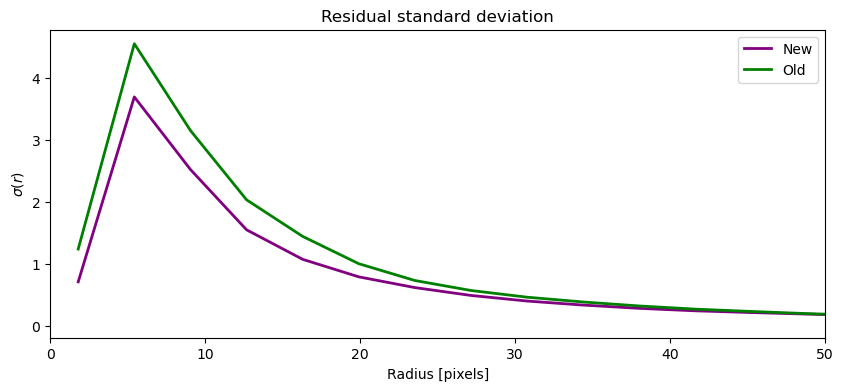

In [10]:
plt.figure(figsize=(10,4))
plt.plot(r_mid, mean_sigma_new, lw=2, color='purple', label='New')
plt.plot(r_mid_old, mean_sigma_old, lw=2, color='green', label='Old')
plt.xlabel("Radius [pixels]")
plt.xlim(0,50)
plt.ylabel(r"$\sigma(r)$")
plt.title("Residual standard deviation")
plt.legend()
plt.show()

In [15]:
def inverse_variance_profile(tr, nbins=50, scale=1e30):

    profiles = []
    sigmas = []
    radii = []


    for obj in tr.items:

        residual = obj.res/obj.tg #* scale
        if not hasattr(obj, "tgcen"):
            obj.find_centers()
        r, prof, sig = radial_profile_with_sigma( residual, obj.tgcen, nbins=nbins )

        profiles.append(prof)
        sigmas.append(sig)
        radii.append(r)

    profiles = np.array(profiles)
    sigmas = np.array(sigmas)
    r = radii[0]

    weights = np.zeros_like(sigmas)
    valid = ( np.isfinite(profiles) & np.isfinite(sigmas) & (sigmas > 0) )
    weights[valid] = 1 / sigmas[valid]**2

    weight_sum = np.sum(weights, axis=0)
    norm_weights = np.zeros_like(weights)
    good = weight_sum > 0
    norm_weights[:, good] = ( weights[:, good] / weight_sum[good] )

    weighted_profile = np.sum( norm_weights * profiles, axis=0 )
    weighted_sigma = np.zeros_like(weighted_profile)
    weighted_sigma[good] = np.sqrt( 1 / weight_sum[good] )


    return r, weighted_profile, weighted_sigma, profiles, sigmas

r_old, prof_old, sig_old, profiles_old, sigmas_old = inverse_variance_profile( old_masks_trial, nbins=200 )
r_new, prof_new, sig_new, profiles_new, sigmas_new = inverse_variance_profile( new_masks_trial, nbins=200 )


(0.0, 10.0)

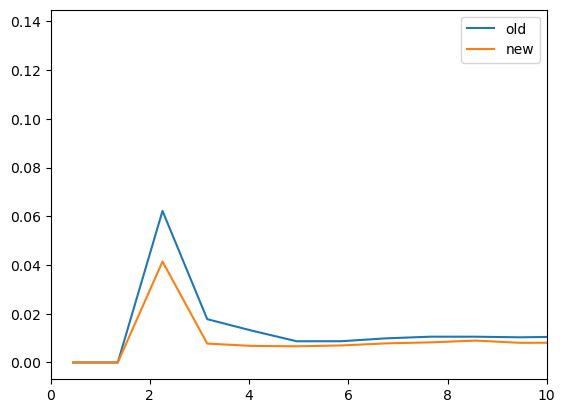

In [16]:
plt.plot(r_old, sig_old, label='old')
plt.plot(r_new, sig_new, label='new')
plt.legend()
plt.xlim(0,10)

Text(0.5, 1.0, 'Inverse Variance - Weighted Residuals Profile')

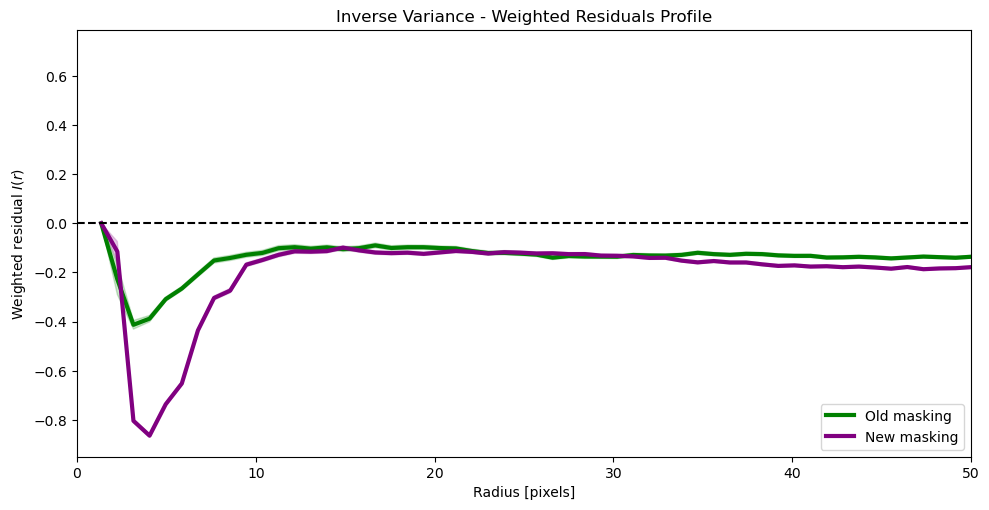

In [17]:

plt.figure(figsize=(10,5))

plt.plot( r_old, prof_old, color="green", lw=3, label="Old masking" )
plt.fill_between( r_old, prof_old-sig_old, prof_old+sig_old, color="green", alpha=0.2 )

plt.plot( r_new, prof_new, color="purple", lw=3, label="New masking" )
plt.fill_between( r_new, prof_new-sig_new, prof_new+sig_new, color="purple", alpha=0.2 )

plt.axhline( 0, color="black", linestyle="--" )
plt.xlim(0,50)
plt.xlabel("Radius [pixels]")
plt.ylabel(r"Weighted residual $I(r)$")
plt.legend(loc='lower right')
plt.tight_layout()
plt.title('Inverse Variance - Weighted Residuals Profile')

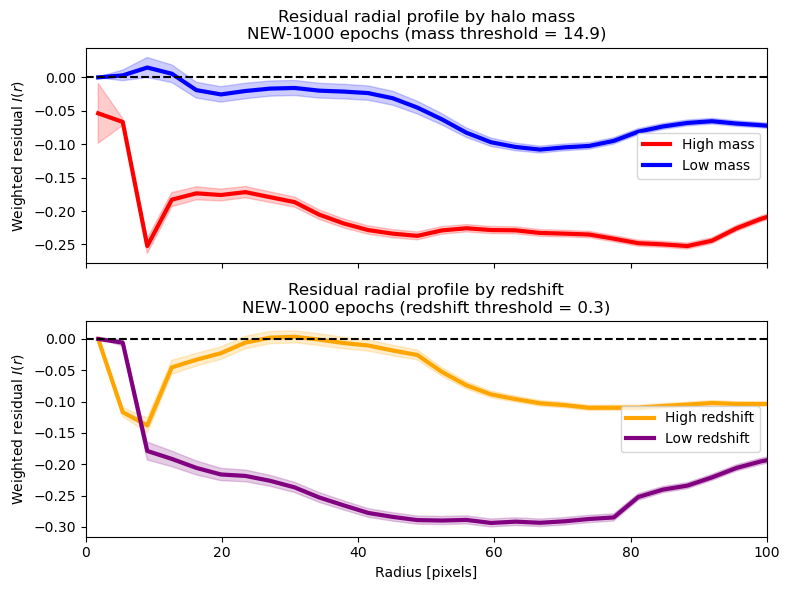

In [21]:
tr=new_masks_trial

tr_high_mass = tr.high_mass()
tr_low_mass = tr.low_mass()

tr_high_z = tr.high_redshift()
tr_low_z = tr.low_redshift()

mass_threshold, z_threshold = tr.mass_threshold, tr.z_threshold

r_hm, prof_hm, sig_hm, _, _ = inverse_variance_profile(tr_high_mass, nbins=50)
r_lm, prof_lm, sig_lm, _, _ = inverse_variance_profile(tr_low_mass, nbins=50)

r_hz, prof_hz, sig_hz, _, _ = inverse_variance_profile(tr_high_z, nbins=50)
r_lz, prof_lz, sig_lz, _, _ = inverse_variance_profile(tr_low_z, nbins=50)




fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

ax = axes[0]

ax.plot(r_hm, prof_hm, color="red", lw=3, label="High mass")
ax.fill_between(r_hm, prof_hm-sig_hm, prof_hm+sig_hm, color="red", alpha=0.2)

ax.plot(r_lm, prof_lm, color="blue", lw=3, label="Low mass")
ax.fill_between(r_lm, prof_lm-sig_lm, prof_lm+sig_lm, color="blue", alpha=0.2)

ax.axhline(0, color="black", linestyle="--")

ax.set_ylabel(r"Weighted residual $I(r)$")
ax.set_title(
    f"Residual radial profile by halo mass\n"
    f"NEW-1000 epochs (mass threshold = {mass_threshold:.3})"
)
ax.set_xlim(0, 100)
ax.legend(loc="center right")


# --- Bottom subplot: redshift ---
ax = axes[1]

ax.plot(r_hz, prof_hz, color="orange", lw=3, label="High redshift")
ax.fill_between(r_hz, prof_hz-sig_hz, prof_hz+sig_hz, color="orange", alpha=0.2)

ax.plot(r_lz, prof_lz, color="purple", lw=3, label="Low redshift")
ax.fill_between(r_lz, prof_lz-sig_lz, prof_lz+sig_lz, color="purple", alpha=0.2)

ax.axhline(0, color="black", linestyle="--")

ax.set_xlabel("Radius [pixels]")
ax.set_ylabel(r"Weighted residual $I(r)$")
ax.set_title(
    f"Residual radial profile by redshift\n"
    f"NEW-1000 epochs (redshift threshold = {z_threshold:.1})"
)
ax.set_xlim(0, 100)
ax.legend(loc="center right")


plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Fractional residual')

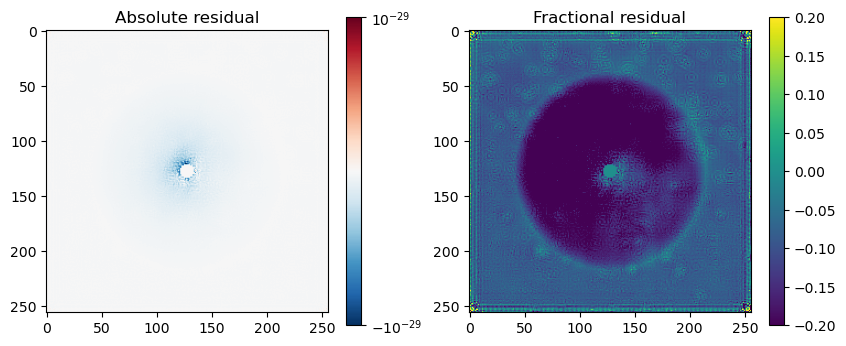

In [245]:
fig,ax = plt.subplots(1,2, figsize=(10,4))

im0 = ax[0].imshow(tr.items[10].res, cmap='RdBu_r', norm=mcolors.SymLogNorm( linthresh=0.1, linscale=1.0, vmin=-1e-29, vmax=1e-29 ) )
plt.colorbar(im0, ax=ax[0])
im1 = ax[1].imshow(tr.items[10].res/tr.items[10].tg, vmin=-0.2, vmax=0.2)
plt.colorbar(im1, ax=ax[1])
ax[0].set_title('Absolute residual')
ax[1].set_title('Fractional residual')